In [7]:
import os
import numpy as np
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [8]:
# Path and categories
# Add 'r' before the quotes to treat backslashes as literal text
data_path = r'D:\BE. CSE\Sem 6\IoT_lab\sr\baby_cry_detector\dataset'
categories = ['baby_cry', 'baby_laugh', 'noise', 'silence']


In [9]:
# Parameters
sr = 22050  # Sample rate
duration = 5  # seconds
max_len = sr * duration

In [10]:

def extract_features(file_path, n_mfcc=40):
    try:
        y, sr = librosa.load(file_path, sr=22050, duration=duration)
        if len(y) < max_len:
            y = np.pad(y, (0, max_len - len(y)))
        else:
            y = y[:max_len]
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc = mfcc.astype(np.float32)
        return mfcc
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

def load_dataset():
    X, y = [], []
    for label in categories:
        folder_path = os.path.join(data_path, label)
        for filename in os.listdir(folder_path):
            if filename.endswith('.wav'):
                file_path = os.path.join(folder_path, filename)
                features = extract_features(file_path)
                if features is not None:
                    X.append(features)
                    y.append(label)
    return np.array(X), np.array(y)


Loading dataset...


C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 214, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 107, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 19, 107, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 105, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 52, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 52, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 26624)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,408,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,427,716 (13.08 MB)

 Trainable params: 3,427,524 (13.07 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 187ms/step - accuracy: 0.6598 - loss: 3.8355 - val_accuracy: 0.1233 - val_loss: 21.4838
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.8625 - loss: 1.4939 - val_accuracy: 0.3151 - val_loss: 8.2191
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.9313 - loss: 0.7670 - val_accuracy: 0.3288 - val_loss: 6.9282
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.9588 - loss: 0.2617 - val_accuracy: 0.4521 - val_loss: 7.0158
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.9725 - loss: 0.1181 - val_accuracy: 0.4932 - val_loss: 6.9581
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.9897 - loss: 0.0292 - val_accuracy: 0.5616 - val_loss: 6.5544
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.9931 - loss: 0.0113 - val_accuracy: 0.5479 - val_loss: 5.9406
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.9897 - loss: 0.0289 - val_accuracy: 0

Test accuracy: 0.88
Model saved as baby_sound_classifier.h5


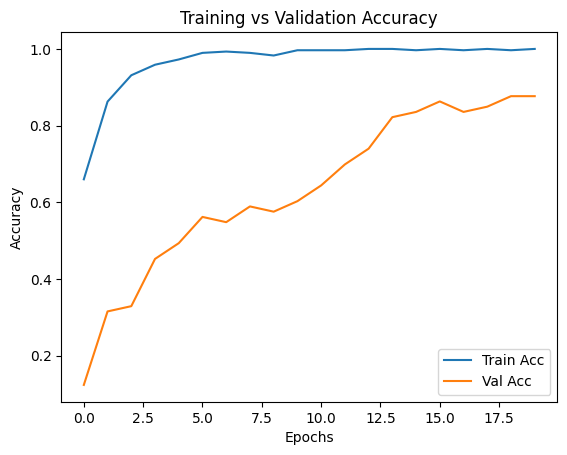

In [11]:

print("Loading dataset...")
X, y = load_dataset()
X = X[..., np.newaxis]  # (samples, 40, time_steps, 1)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = tf.keras.utils.to_categorical(y_encoded, num_classes=len(categories))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42, stratify=y_cat)

# Model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(40, X.shape[2], 1)),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train
history = model.fit(X_train, y_train, epochs=20, batch_size=32,
                    validation_data=(X_test, y_test))

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.2f}")

# Save model
model.save("baby_sound_classifier.h5")
print("Model saved as baby_sound_classifier.h5")

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

In [12]:
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras.models import load_model

# Load your trained model
model = load_model("baby_sound_classifier.h5")

# Your label encoder categories
categories = ['baby_cry', 'baby_laugh', 'noise', 'silence']

def extract_features(file_path, sr=22050, duration=5, n_mfcc=40):
    try:
        y, _ = librosa.load(file_path, sr=sr, duration=duration)
        max_len = sr * duration
        if len(y) < max_len:
            y = np.pad(y, (0, max_len - len(y)))
        else:
            y = y[:max_len]
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc = mfcc.astype(np.float32)
        mfcc = mfcc[..., np.newaxis]  # Add channel dimension
        return mfcc
    except Exception as e:
        print(f"Error extracting features: {e}")
        return None

def predict_sound(file_path):
    features = extract_features(file_path)
    if features is not None:
        features = np.expand_dims(features, axis=0)  # (1, 40, time_steps, 1)
        prediction = model.predict(features)
        predicted_index = np.argmax(prediction)
        predicted_label = categories[predicted_index]
        confidence = prediction[0][predicted_index]
        print(f"Predicted: {predicted_label} (Confidence: {confidence:.2f})")
    else:
        print("Could not extract features from the file.")

# Example usage
# test_file = "E:\\baby cry detector\\dataset\\baby_laugh\\laugh_2.m4a_2.wav" # Replace with your test .wav file path
# Example using an existing file from your dataset
test_file = r'D:\BE. CSE\Sem 6\IoT_lab\sr\baby_cry_detector\dataset\baby_laugh\laugh_1.wav'
predict_sound(test_file)

Error extracting features: [Errno 2] No such file or directory: 'D:\\BE. CSE\\Sem 6\\IoT_lab\\sr\\baby_cry_detector\\dataset\\baby_laugh\\laugh_1.wav'
Could not extract features from the file.


C:\Users\Admin\AppData\Local\Temp\ipykernel_24852\1274630096.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(file_path, sr=sr, duration=duration)
C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Confusion Matrix:
 [[ 7  0  1  0]
 [ 1 20  1  0]
 [ 4  0 18  0]
 [ 0  0  2 19]]

Classification Report:
              precision    recall  f1-score   support

    baby_cry       0.58      0.88      0.70         8
  baby_laugh       1.00      0.91      0.95        22
       noise       0.82      0.82      0.82        22
     silence       1.00      0.90      0.95        21

    accuracy                           0.88        73
   macro avg       0.85      0.88      0.86        73
weighted avg       0.90      0.88      0.88        73



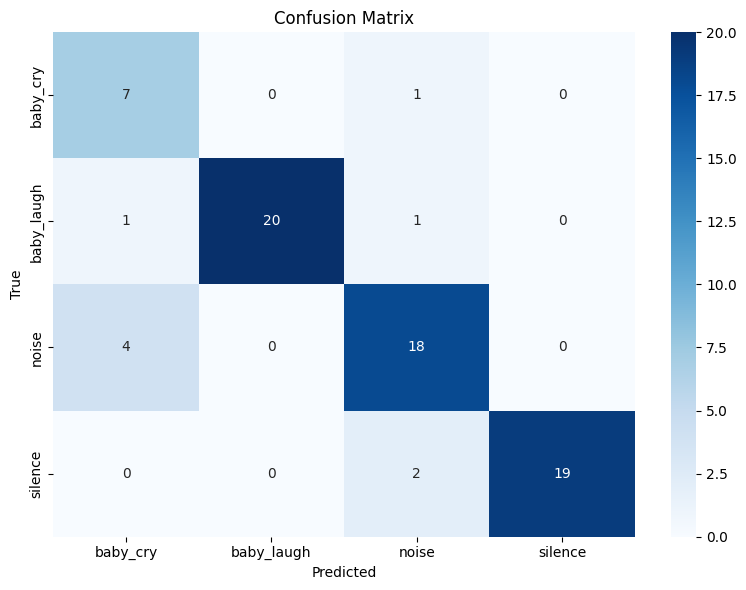

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Assuming you already have:
# - X_test: your test features
# - y_test: your one-hot encoded test labels
# - model: your trained model
# - categories: list of class names

# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=categories))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [14]:
import tensorflow as tf

# Load your trained model
model = tf.keras.models.load_model("baby_sound_classifier.h5")

# Convert to TFLite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the .tflite file
with open("baby_sound_classifier.tflite", "wb") as f:
    f.write(tflite_model)

print("Model converted and saved as baby_sound_classifier.tflite")


INFO:tensorflow:Assets written to: C:\Users\Admin\AppData\Local\Temp\tmpsegg2_ol\assets


INFO:tensorflow:Assets written to: C:\Users\Admin\AppData\Local\Temp\tmpsegg2_ol\assets


Saved artifact at 'C:\Users\Admin\AppData\Local\Temp\tmpsegg2_ol'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 216, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2453916409120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2453916413696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2453916495440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2453916496144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2453916492272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2453916494560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2453916497728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2453916570320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2453916572784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2453916577184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2453916

In [15]:
interpreter = tf.lite.Interpreter(model_path="baby_sound_classifier.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

categories = ['baby_cry', 'baby_laugh', 'noise', 'silence']

C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [1]:

import numpy as np
import librosa
import tensorflow as tf
import tkinter as tk
from tkinter import filedialog, messagebox
import pygame  # Added for audio playback

# --- Initialize Pygame Mixer ---
pygame.mixer.init()

# --- Load the TFLite Interpreter ---
interpreter = tf.lite.Interpreter(model_path="baby_sound_classifier.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# CORRECTED ORDER: Alphabetical based on your notebook's LabelEncoder logic
categories = ['baby_cry', 'baby_laugh', 'noise', 'silence']

def predict_sound(file_path):
    try:
        # 1. Play the sound immediately [New Feature]
        pygame.mixer.music.load(file_path)
        pygame.mixer.music.play()

        # 2. Load and preprocess (Match training: 22050Hz, 5 seconds)
        y, sr = librosa.load(file_path, sr=22050, duration=5)
        target_length = 22050 * 5
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)))
        else:
            y = y[:target_length]
        
        # 3. Extract MFCC
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        
        # 4. Shape fixing (Ensure width matches 216)
        expected_width = 216 
        if mfcc.shape[1] < expected_width:
            mfcc = np.pad(mfcc, ((0, 0), (0, expected_width - mfcc.shape[1])))
        else:
            mfcc = mfcc[:, :expected_width]
        
        mfcc = mfcc.astype(np.float32)
        input_data = np.expand_dims(np.expand_dims(mfcc, axis=0), axis=-1)

        # 5. Inference
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details[0]['index'])
        
        # 6. Result
        predicted_index = np.argmax(output_data)
        result = categories[predicted_index]
        confidence = output_data[0][predicted_index] * 100
        return result, confidence
    except Exception as e:
        return f"Error: {str(e)}", 0

def select_file():
    file_path = filedialog.askopenfilename(
        title="Select Baby Sound File",
        filetypes=(("WAV files", "*.wav"), ("All files", "*.*"))
    )
    if file_path:
        label_status.config(text=f"Playing & Processing: {file_path.split('/')[-1]}...")
        root.update()
        
        result, confidence = predict_sound(file_path)
        
        messagebox.showinfo("Prediction Result", f"Sound Identified: {result}\nConfidence: {confidence:.2f}%")
        label_status.config(text="Waiting for file selection...")

# --- GUI Setup ---
root = tk.Tk()
root.title("Baby Cry Detector - Player & Predictor")
root.geometry("400x250")

label_title = tk.Label(root, text="Baby Cry Detector", font=("Arial", 16, "bold"))
label_title.pack(pady=10)

btn_browse = tk.Button(root, text="Select & Play Audio (.wav)", command=select_file, 
                       height=2, width=25, bg="#4CAF50", fg="white", font=("Arial", 10, "bold"))
btn_browse.pack(pady=20)

label_status = tk.Label(root, text="Waiting for file selection...", fg="blue")
label_status.pack()

# Stop audio if window is closed
def on_closing():
    pygame.mixer.music.stop()
    root.destroy()

root.protocol("WM_DELETE_WINDOW", on_closing)
root.mainloop()

pygame 2.6.1 (SDL 2.28.4, Python 3.10.11)
Hello from the pygame community. https://www.pygame.org/contribute.html


C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
